# Importo librerias

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
from scipy.stats import chi2

from google.colab import drive
drive.mount('/content/drive')


# Parametros para el tamanio del texto
rc = {
    'legend.fontsize': 18,
    'axes.titlesize': 20,
    'font.size': 16,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'axes.labelsize': 22,
}
plt.rcParams.update(rc)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Explicacion

La idea es a partir de imagenes del perfil de un vortice, poder comparar el modelo de Rankine y el de burgers sobre como es la forma

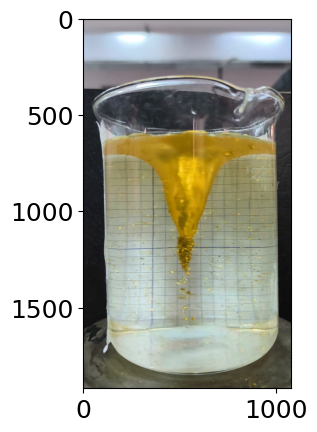

In [37]:
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/perfil vortice/ejemplo.png", cv2.IMREAD_UNCHANGED)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

En primer lugar utilizando el software aseprite, se obtuvo el perfil del vertice para 3 frecuencias de rotacion del buzo distintas

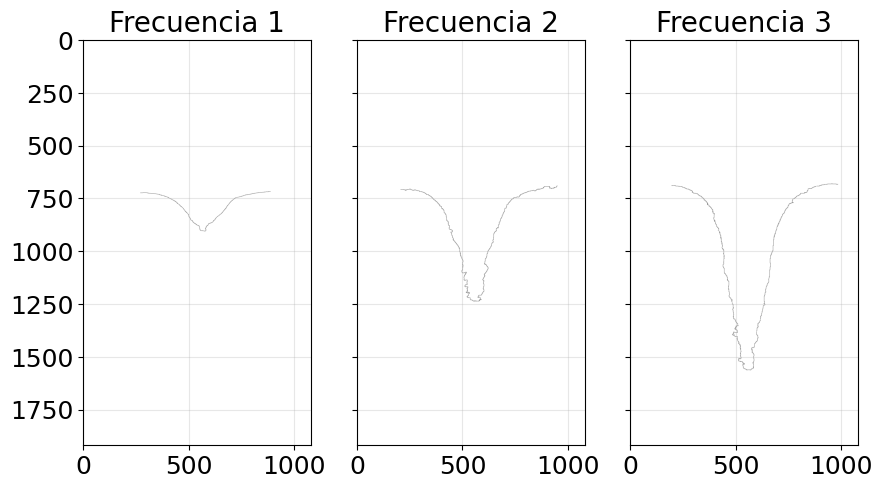

In [38]:
imagenes = [
    "/content/drive/MyDrive/Colab Notebooks/perfil vortice/Frecuencia 1.png",
    "/content/drive/MyDrive/Colab Notebooks/perfil vortice/Frecuencia 2.png",
    "/content/drive/MyDrive/Colab Notebooks/perfil vortice/Frecuencia 3.png"
]

fig, axes = plt.subplots(1, 3, figsize=(10, 18), sharey=True)
for ax, img_path in zip(axes, imagenes):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    nombre = os.path.basename(img_path).strip(".png")
    ax.imshow(img)
    ax.set_title(f"{nombre}")
    ax.grid(True, alpha = 0.3)

# Funcion para buscar el eje de simetria del vortice

Para cada recta x = xc, reflejo toda la imagen a traves de esa recta. Luego calculo la distancia minima de cada punto de la imagen reflejada a la original y sumo todas esas distancias, que es el error. Barro todos los pixeles de x como xc, y veo cual minimiza el error, asi tengo el xc optimo que seria el eje de simetria y lo que va a ser el eje z y r = 0 (necesario para ajustar con los modelos).

In [39]:
# devuelve la distancia minima entre un punto reflejado (xr, yr) y todos los puntos originales (xs, ys)
def calcular_minima_distancia(xs, ys, xr, yr):
    distancias = np.sqrt((xs - xr)**2 + (ys - yr)**2)
    return np.min(distancias)

# Para un dado xc, reflejo todos los puntos respecto de ahi, y busco la distancia minima entre la imagen reflejo y la original para cada punto,
# luego sumo, la idea es ver que xc da el menor error.
def error_simetria(xs, ys, xc):
    errores = []
    # reflejo respecto a x = xc
    x_reflejado = 2 * xc - xs

    for i in range(len(x_reflejado)):
        xr = x_reflejado[i]
        yr = ys[i]
        # calculo la distancia minima respecto para cada punto reflejo a la imagen original
        dmin = calcular_minima_distancia(xs, ys, xr, yr)
        errores.append(dmin**2)

    return np.mean(errores)

def buscar_eje_simetria(xs, ys, n_pasos=100):
    xmin, xmax = np.min(xs), np.max(xs)
    lista_xc = np.arange(xmin, xmax, step = 1)
    errores = []

    for xc in lista_xc:
        e = error_simetria(xs, ys, xc)
        errores.append(e)

    # guardo el xc con menor error, el optimo
    idx_min = np.argmin(errores)
    xc_opt = lista_xc[idx_min]
    return xc_opt, errores, lista_xc

# funcion para graficar los errores y la imagen espejo
def graficar_errores_imagen_espejo(lista_xc, errores, xs, xc_optimo):
  fig, ax = plt.subplots(2, 1, figsize=(12,12), sharex = True)
  ax[0].scatter(lista_xc, errores, s = 1, color = "purple", label = "RMS(Xc)")
  ax[0].grid(True)
  ax[0].set_ylabel("RMS")
  ax[0].legend()

  # grafico para el reflejado
  x_reflejado = 2 * xc_optimo- xs
  ax[1].scatter(xs, ys, color="blue", s=3, label="Original")
  ax[1].scatter(x_reflejado, ys, color="red", s=3, alpha=0.5, label="Reflejado")
  ax[1].axvline(x=xc_optimo, color="green", linestyle="--", label=f"Eje óptimo x={xc_optimo:.1f}")
  ax[1].grid(True)
  ax[1].legend()
  ax[1].set_xlabel("Xc")

# Veo como funciona para la frecuencia 2

In [40]:
# Leer la imagen en RGBA
img = cv2.imread(imagenes[1], cv2.IMREAD_UNCHANGED)


# el contorno esta en pixeles negoros y todo lo demas es transparente
b, g, r, a = cv2.split(img)

# creo una mascara donde hay pixeles negros (r=g=b=0 y alfa > 0)
mask = (r == 0) & (g == 0) & (b == 0) & (a > 0)

# Transformo esa mascara a coordenadas en x e y
ys, xs = np.where(mask)
ys = -ys # Paso a sistema matematico inviertiendo el eje y

Obtengo el eje de simetria, cambio el sistema de referencia

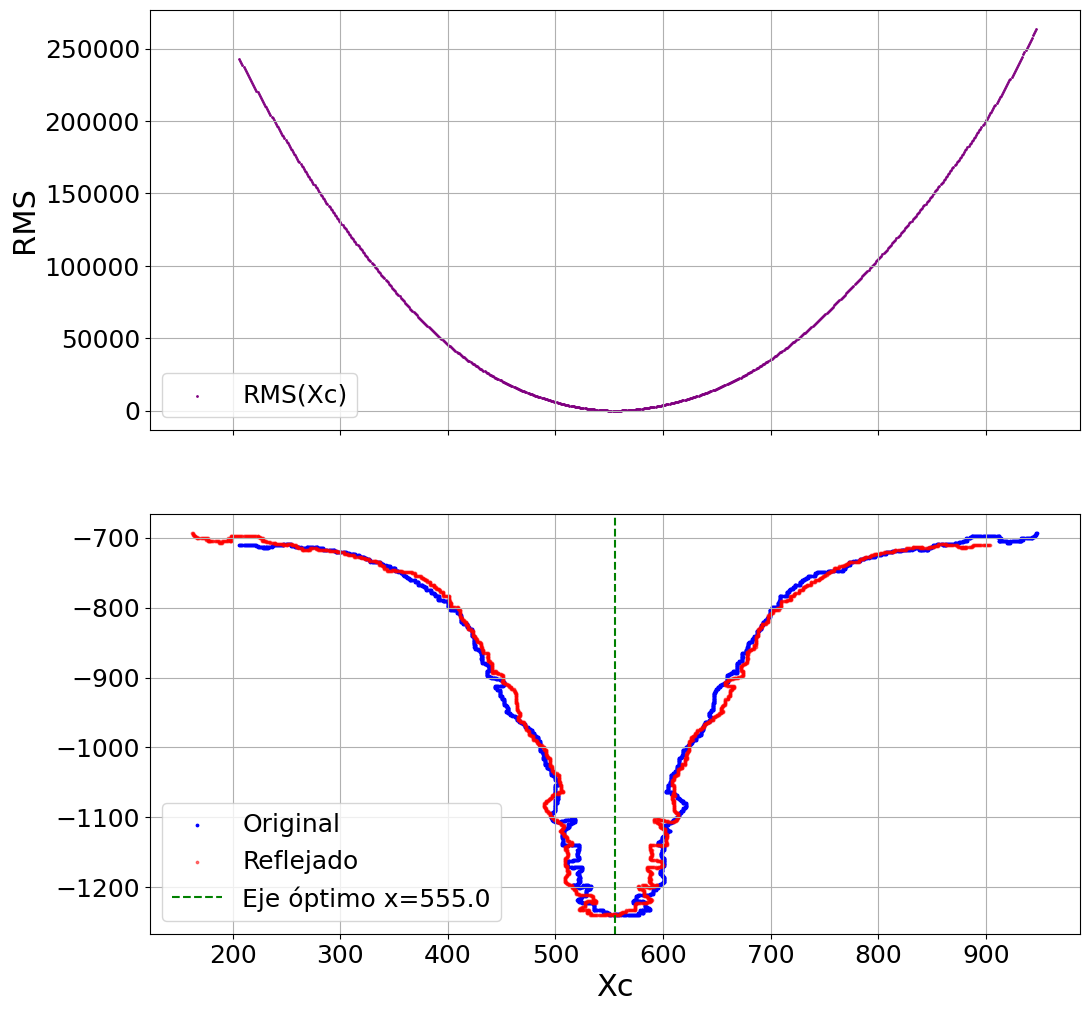

In [41]:
# Obtengo la recta x = xc, tal que hay maxima simetria alrededor
xc_optimo, errores, lista_xc = buscar_eje_simetria(xs, ys)

# Cambio el sistema de referencia a ese, centro en (r,z) = (0,0)
x = xs - xc_optimo
# Busco el minimo de y, en la recta x = xc
mask_centro = (xs == xc_optimo)
y0 = np.min(ys[mask_centro])
# Defino z ahora
z = ys - y0

# Cambio de unidades usando la escala obtenida
px_to_mm = 60 / 583.11  # mm/pixel
x_mm = x * px_to_mm
z_mm = z * px_to_mm
z_err = np.ones_like(1) # 1 mm de error para todos
x_err = np.ones_like(1) # 1 mm de error para todos

r_mm = np.abs(x_mm)
r_err = np.abs(x_err)

graficar_errores_imagen_espejo(lista_xc, errores, xs, xc_optimo)

Bineo los datos

In [42]:
def binear_datos(r_mm, z_mm, ancho_bin, r_err_ind=1.0, z_err_ind=1.0):
    """
    Promedia los datos (r, z) por intervalos radiales y propaga errores instrumentales.
    r_err_ind y z_err_ind son errores individuales (en mm).
    """
    r_min, r_max = np.min(r_mm), np.max(r_mm)
    bins = np.arange(r_min, r_max + ancho_bin, ancho_bin)
    bin_idx = np.digitize(r_mm, bins) - 1

    r_centro, r_centro_err = [], []
    z_promedio, z_err_total = [], []

    for i in range(len(bins) - 1):
        mask = bin_idx == i
        if not np.any(mask):
            continue

        r_vals = r_mm[mask]
        z_vals = z_mm[mask]
        N = len(r_vals)

        # centro del bin
        r_c = 0.5 * (bins[i] + bins[i + 1])
        r_centro.append(r_c)

        # errores en r y z propagados
        if N > 1:
          r_disp = np.std(r_vals, ddof=1)
          z_disp = np.std(z_vals, ddof=1)
        else:
          r_disp = 0
          z_disp = 0
        # errores totales (instrumental + dispersión)
        r_err = np.sqrt((ancho_bin / 2)**2 + (r_err_ind**2) / N)
        z_err = np.sqrt(z_disp**2 + (z_err_ind**2) / N)

        r_centro_err.append(r_err)
        z_promedio.append(np.mean(z_vals))
        z_err_total.append(z_err)

    return (
        np.array(r_centro),
        np.array(r_centro_err),
        np.array(z_promedio),
        np.array(z_err_total)
    )

Defino las funciones de ajuste

In [43]:
g = 9.81 * 1000 # mm
def h_rankine(r, Omega, a):
    """
    modelo rankine:
        z(r) = (Omega^2 / 2g) * r^2 si r <= a

        z(r) = (Omega^2 * a^2 / g) * (1 - a^2 / (2 * r^2)) si r >= a
    """
    r = np.array(r)
    r = np.where(r == 0, 1e-6, r) # singularidad
    h = np.where(r <= a, (0.5 * Omega**2 / g) * r**2, Omega**2 * a**2 /g * (1 - 0.5 * a**2 / r**2))
    return h

def h_burgers(r, Omega, a):
    """
    modelo Burgers:
    z(r) = (Omega^2 * a^4 / g) * Integral_0^r [ (1 - exp(-rho^2 / a^2))^2 / rho^3 ] d_rho
    """
    r = np.array(r, dtype=float)
    r_max = np.max(r)
    # Evito singularidad en 0
    r_grid = np.linspace(1e-6, r_max, 3000)
    integrando = (1 - np.exp(-r_grid**2 / a**2))**2 / r_grid**3
    integral = cumulative_trapezoid(integrando, r_grid, initial=0)
    # interpolo la integral para cada r
    integral_interp = np.interp(np.abs(r), r_grid, integral)
    return (Omega**2) * (a**4 / g) * integral_interp

In [44]:
def procesar_imagen(img_path, px_to_mm=60/583.11, rmax = 50, tamanio_bin = 1):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    b, g, r, a = cv2.split(img)
    mask = (r == 0) & (g == 0) & (b == 0) & (a > 0)
    ys, xs = np.where(mask)
    ys = -ys  # eje matemático

    # buscar eje de simetría
    xc_optimo, errores, lista_xc = buscar_eje_simetria(xs, ys)

    # cambiar referencia
    x = xs - xc_optimo
    mask_centro = (xs == xc_optimo)
    y0 = np.min(ys[mask_centro])
    z = ys - y0

    # pasar a mm
    x_mm = x * px_to_mm
    z_mm = z * px_to_mm
    z_err = np.ones_like(z_mm) * 1  # 1 mm
    x_err = np.ones_like(x_mm) * 1

    r_mm = np.abs(x_mm)
    r_err = np.abs(x_err)

    # bineo
    r_centro, r_centro_err, z_promedio, z_error = binear_datos(r_mm, z_mm, tamanio_bin)

    mask = (r_centro < rmax)
    r_centro = r_centro[mask]
    z_promedio = z_promedio[mask]
    z_error = z_error[mask]
    r_centro_err = r_centro_err[mask]


    return r_centro, r_centro_err, z_promedio, z_error

Genero un plot con los datos, y el ajuste de cada modelo para las 3 frecuencias

Frecuencia 1
Rankine:
Omega = 47.979 ± 0.424
a = 9.077 ± 0.092
χ²_red = 4.4138, p = 3.163e-29
Burgers:
Omega = 61.685 ± 0.600
a = 8.617 ± 0.099
χ²_red = 1.0485, p = 0.37121

Frecuencia 2
Rankine:
Omega = 84.344 ± 0.314
a = 8.793 ± 0.035
χ²_red = 7.6148, p = 2.1295e-80
Burgers:
Omega = 107.792 ± 0.526
a = 8.347 ± 0.045
χ²_red = 1.3612, p = 0.018671

Frecuencia 3
Rankine:
Omega = 92.679 ± 0.389
a = 10.339 ± 0.047
χ²_red = 0.97893, p = 0.5315
Burgers:
Omega = 126.816 ± 0.615
a = 9.111 ± 0.048
χ²_red = 1.431, p = 0.0075095



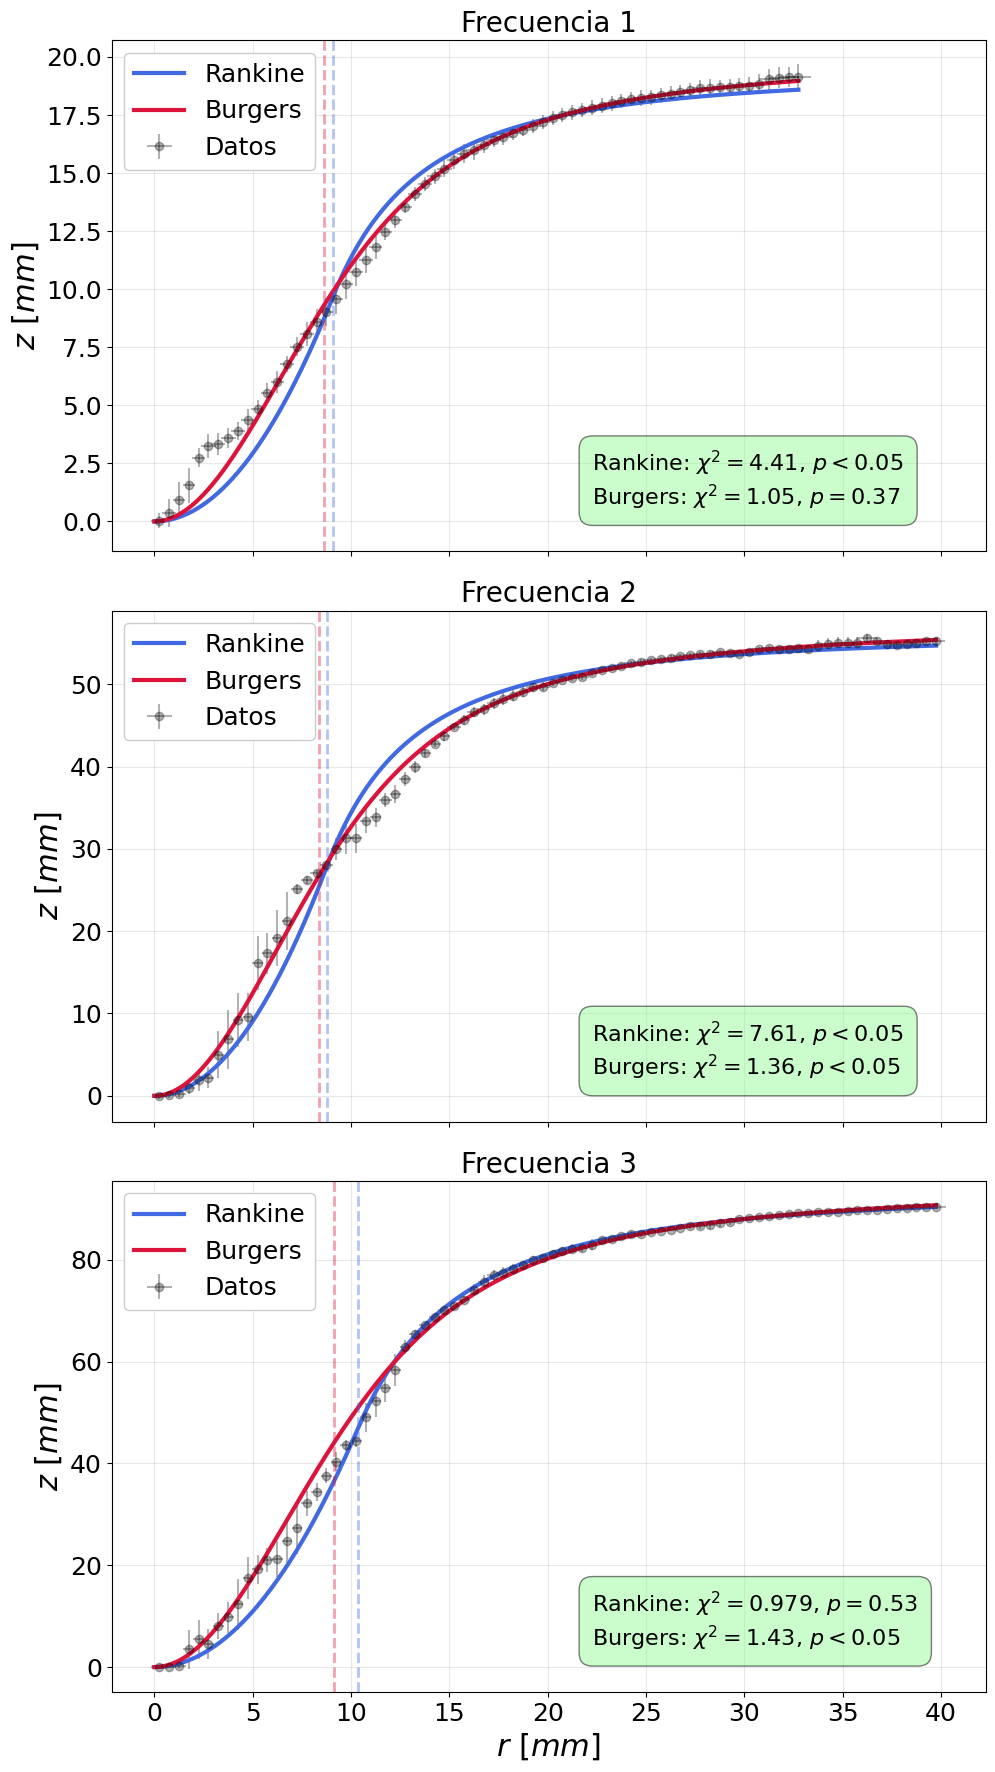

In [45]:
colores = {"Rankine": "royalblue", "Burgers": "crimson", "Datos": "black"}


# figura de 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 18), sharex=True)

for ax, img_path in zip(axes, imagenes):
    r_centro, r_centro_err, z_promedio, z_error = procesar_imagen(
        img_path, rmax=40, tamanio_bin=0.5)

    # ajuste Rankine
    if ax == axes[-1]:
        p0_rankine = (80, 10)
    else:
        p0_rankine = (10, 10)

    popt_R, pcov_R = curve_fit(h_rankine, r_centro, z_promedio,
        sigma=z_error, absolute_sigma=True, p0=p0_rankine, maxfev=20000)
    Omega_R, a_R = popt_R
    err_R = np.sqrt(np.diag(pcov_R))


    # ajuste Burgers
    p0_burgers = (10, 10)
    popt_B, pcov_B = curve_fit(h_burgers, r_centro, z_promedio,
        sigma=z_error, absolute_sigma=True, p0=p0_burgers, maxfev=20000)

    Omega_B, a_B = popt_B
    err_B = np.sqrt(np.diag(pcov_B))

    # curvas ajustadas
    r_fit = np.linspace(0, np.max(r_centro), 500)
    z_R = h_rankine(r_fit, *popt_R)
    z_B = h_burgers(r_fit, *popt_B)

    # datos experimentales
    ax.errorbar(r_centro, z_promedio,xerr=r_centro_err, yerr=z_error,
        fmt='o', color=colores["Datos"], alpha=0.3, label="Datos")

    ax.plot(r_fit, z_R, '-', color=colores["Rankine"], lw=3, label="Rankine")
    ax.plot(r_fit, z_B, '-', color=colores["Burgers"], lw=3, label="Burgers")
    ax.axvline(a_B, color=colores["Burgers"], ls="--", lw=2, alpha=0.4)
    ax.axvline(a_R, color=colores["Rankine"], ls="--", lw=2, alpha=0.4)

    # ch2 y p-valor
    chi2_R = np.sum(((z_promedio - h_rankine(r_centro, *popt_R)) / z_error)**2)
    chi2_B = np.sum(((z_promedio - h_burgers(r_centro, *popt_B)) / z_error)**2)
    dof_R = len(z_promedio) - len(popt_R)
    dof_B = len(z_promedio) - len(popt_B)
    chi2_red_R = chi2_R / dof_R
    chi2_red_B = chi2_B / dof_B
    p_R = chi2.sf(chi2_R, dof_R)
    p_B = chi2.sf(chi2_B, dof_B)


    # titulo
    nombre = os.path.basename(img_path).strip(".png")
    ax.set_title(nombre)

    # imprimo resultados
    print(nombre)
    print(f"Rankine:")
    print(f"Omega = {Omega_R:.3f} ± {err_R[0]:.3f}")
    print(f"a = {a_R:.3f} ± {err_R[1]:.3f}")
    print(f"χ²_red = {chi2_red_R:.5g}, p = {p_R:.5g}")
    print(f"Burgers:")
    print(f"Omega = {Omega_B:.3f} ± {err_B[0]:.3f}")
    print(f"a = {a_B:.3f} ± {err_B[1]:.3f}")
    print(f"χ²_red = {chi2_red_B:.5g}, p = {p_B:.5g}")
    print("")


    def format_chi2_red(x):
        """Formatea ch2_red con tres cifras significativas,
        mostrando 3 decimales si es menor que 1, o solo dos si es menor a 10 y mayor que 1."""
        if x < 10 and x > 1:
            return f"{x:.2f}"
        if x < 1:
            return f"{x:.3f}"
        else:
            return f"{x:.3g}"

    def format_pvalue(p, threshold=0.05):
        """
        Retorna '< 0.05' si p < threshold, o 2 cifras significatuivas si no.
        """
        if p < threshold:
            return "< 0.05"
        else:
            return f"= {p:.2g}"

    # armo el texto para el chi2
    textstr_chi2 = (
        rf"Rankine: $\chi^2 = {format_chi2_red(chi2_red_R)}$, "
        f"$p {format_pvalue(p_R)}$\n"
        rf"Burgers: $\chi^2 = {format_chi2_red(chi2_red_B)}$, "
        f"$p {format_pvalue(p_B)}$"
    )

    # estadisticos
    ax.text(
        0.55, 0.2, textstr_chi2, transform=ax.transAxes,
        color="black", va='top', ha='left',
        bbox=dict(facecolor='palegreen', alpha=0.5,
                  edgecolor='black', boxstyle='round,pad=0.6')
    )


    ax.legend(loc='upper left', framealpha=1)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both')


# etiquetas de ejes
for ax in axes:
    ax.set_ylabel(r"$z$ $[mm]$")
# el eje x compartido
axes[-1].set_xlabel(r"$r$ $[mm]$")

plt.tight_layout()
plt.savefig("perfil_vortice.svg", format="svg", bbox_inches="tight")
plt.show()